In [ ]:
# ═══════════════════════════════════════════════════════════════
# STANDALONE EVALUATION
# ═══════════════════════════════════════════════════════════════

import json
import re
import random
import numpy as np
import torch
from pathlib import Path
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import PeftModel

# CONFIG
ADAPTER_PATH = "auditor_agent_model/lora_adapter"
BASE_MODEL = "microsoft/Phi-3-mini-4k-instruct"
DATASET_PATH = "auditor_dataset_final.jsonl"
OUTPUT_DIR = Path("eval_output")
OUTPUT_DIR.mkdir(exist_ok=True)

# Load system prompt
AUDITOR_SYSTEM_PROMPT = '''You are the strict architecture auditor.

Audit the architecture plan against:
- frozen confirmed requirements
- rich requirement notes
- cumulative issue ledger
- revision memory
- prior audit history

Main goal:
- First, verify whether previously reported issues were actually fixed.
- Second, identify the most important remaining weaknesses.
- Third, explain clearly why the score stayed the same, improved, or dropped.

Rules:
- Use stable issue IDs whenever the same issue still exists.
- Mark each issue status as one of: unresolved, resolved, downgraded, new.
- Re-check prior unresolved issues before creating new ones.
- If an earlier issue was fixed, keep the same issue ID and mark it resolved.
- If an earlier issue still exists, keep the same issue ID and explain what is still missing.
- Only create a new issue ID if the problem is materially different from previous issues.
- Score the plan against an absolute rubric, not against any approval threshold.
- Do not try to make the plan pass or fail a gate.
- Be willing to score below 9 if the plan has real weaknesses.
- If the score drops, explain the exact reason for the drop.
- If the score does not improve, explain what blocked improvement.
- Prefer the most important unresolved issues over minor nitpicks.

Return JSON only with:
- thinking_summary
- rubric_scores
- summary
- strengths
- concerns
- blocking_issues
- recommendations
- requirement_conflicts
- issue_updates

rubric_scores must include numeric values from 0 to 10 for:
- requirements_alignment
- architecture_quality
- security
- operability
- internal_consistency

Each requirement_conflicts item must include:
- issue_id, field, current_value, proposed_value, exact_reason, severity

Each issue_updates item must include:
- id, title, severity, status, detail

For each issue_updates.detail:
- State whether the issue was fixed, partially fixed, unchanged, or newly introduced.
- Explain exactly what in the plan caused this judgment.
- If the issue affected the score, explain how.

recommendations should:
- focus on the next highest-impact fixes
- be specific enough for the architect to act on in the next round
- avoid vague advice

summary should:
- briefly explain overall quality
- say whether the round meaningfully improved over the prior round
- mention the main reason the score changed or stayed flat'''

print("System prompt loaded.")

System prompt loaded.


In [ ]:
# ═══════════════════════════════════════════════════════════════
# LOAD THE MODEL
# ═══════════════════════════════════════════════════════════════
from transformers import AutoConfig, AutoModelForCausalLM, BitsAndBytesConfig
import torch
from peft import PeftModel

print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL, trust_remote_code=False)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print("Configuring Phi-3 settings...")
config = AutoConfig.from_pretrained(BASE_MODEL, trust_remote_code=False)

print("Loading base model with quantization...")
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    config=config,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=False, 
    attn_implementation="eager",
    torch_dtype=torch.bfloat16,
)

print("Applying LoRA adapter...")
model = PeftModel.from_pretrained(base_model, ADAPTER_PATH)
model.eval()

print(f"Model loaded. GPU memory: {torch.cuda.memory_allocated() / 1e9:.2f} GB")

Loading tokenizer...


Configuring Phi-3 settings...
Loading base model with quantization...


Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

Applying LoRA adapter...
Model loaded. GPU memory: 2.34 GB


In [3]:
# ═══════════════════════════════════════════════════════════════
# LOAD VALIDATION DATA
# ═══════════════════════════════════════════════════════════════
import hashlib
from collections import defaultdict

def load_jsonl(filepath):
    rows = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                try:
                    rows.append(json.loads(line))
                except:
                    pass
    return rows

raw_data = load_jsonl(DATASET_PATH)
print(f"Loaded {len(raw_data)} rows")

# Reconstruct the same chain-aware split with the same seed
chains = defaultdict(list)
for row in raw_data:
    contract = row.get('input_payload', {}).get('frozenrequirementcontract', {})
    fp = hashlib.sha256(json.dumps(contract, sort_keys=True).encode()).hexdigest()[:16]
    chains[fp].append(row)

chain_ids = list(chains.keys())
rng = random.Random(42)
rng.shuffle(chain_ids)
n_val = max(1, int(len(chain_ids) * 0.15))
val_chain_ids = set(chain_ids[:n_val])

val_rows = []
for cid in val_chain_ids:
    val_rows.extend(chains[cid])

print(f"Validation set reconstructed: {len(val_rows)} rows")

Loaded 799 rows
Validation set reconstructed: 118 rows


In [4]:
import transformers

_OriginalDynamicCache = transformers.cache_utils.DynamicCache

class PatchedDynamicCache(_OriginalDynamicCache):
    @property
    def seen_tokens(self):
        if hasattr(self, '_seen_tokens'):
            return self._seen_tokens
        try:
            return self.get_seq_length()
        except:
            return 0

    @seen_tokens.setter
    def seen_tokens(self, value):
        self._seen_tokens = value

transformers.cache_utils.DynamicCache = PatchedDynamicCache

import sys
for mod_name, mod in sys.modules.items():
    if 'modeling_phi3' in mod_name and hasattr(mod, 'DynamicCache'):
        mod.DynamicCache = PatchedDynamicCache

print("DynamicCache fixed successfully.")

DynamicCache fixed successfully.


In [ ]:
# ═══════════════════════════════════════════════════════════════
# GENERATE AND EVALUATE
# ═══════════════════════════════════════════════════════════════

def generate_audit(model, tokenizer, row, max_new_tokens=1500):
    payload = row.get('input_payload', {})
    auditor_input = {
        "round": payload.get('round', 1),
        "frozenrequirementcontract": payload.get('frozenrequirementcontract', {}),
        "requirements": payload.get('requirements', {}),
        "acceptedexceptions": payload.get('acceptedexceptions', {}),
        "issueledger": payload.get('issueledger', {}),
        "revisionmemory": payload.get('revisionmemory', {}),
        "previousaudits": payload.get('previousaudits', []),
        "reasonerreviews": payload.get('reasonerreviews', {}),
        "specialistsubplans": payload.get('specialistsubplans', {}),
        "plan": payload.get('plan', {}),
        "bestaudit": payload.get('bestaudit', {}),
    }
    user_content = json.dumps(auditor_input, indent=1, ensure_ascii=False)

    messages = [
        {"role": "system", "content": AUDITOR_SYSTEM_PROMPT},
        {"role": "user", "content": user_content},
    ]

    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

    inputs = tokenizer(
        prompt, return_tensors="pt", truncation=True,
        max_length=4096 - max_new_tokens
    )
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=0.1,
            do_sample=True,
            top_p=0.9,
            repetition_penalty=1.1,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    # Decode ONLY the new tokens
    generated_ids = outputs[0][inputs['input_ids'].shape[1]:]
    text = tokenizer.decode(generated_ids, skip_special_tokens=True)
    return text.strip()


def extract_json(text):
    # Try direct parse
    try:
        return json.loads(text)
    except:
        pass
    # Find JSON boundaries
    start = text.find('{')
    end = text.rfind('}')
    if start != -1 and end > start:
        try:
            return json.loads(text[start:end+1])
        except:
            pass
    return None


# Run on validation sample
EVAL_SIZE = min(50, len(val_rows))
eval_sample = random.Random(42).sample(val_rows, EVAL_SIZE)

print(f"Generating on {EVAL_SIZE} validation examples...")

predictions = []
for i, row in enumerate(eval_sample):
    sid = row.get('sample_id', f'val_{i}')
    reference = row.get('target_output', {})

    if (i + 1) % 5 == 0:
        print(f"  [{i+1}/{EVAL_SIZE}] {sid}")

    try:
        generated_text = generate_audit(model, tokenizer, row)
        parsed = extract_json(generated_text)
    except Exception as e:
        print(f"  ERROR on {sid}: {str(e)[:100]}")
        generated_text = ""
        parsed = None

    predictions.append({
        "sample_id": sid,
        "generated_raw": generated_text[:500],
        "generated_parsed": parsed,
        "reference": reference,
        "json_valid": parsed is not None,
    })

    if i < 3:
        print(f"\n  --- Sample {sid} ---")
        print(f"  JSON valid: {parsed is not None}")
        if parsed:
            print(f"  Keys: {list(parsed.keys())[:5]}...")
            rubric = parsed.get('rubricscores', parsed.get('rubric_scores', {}))
            print(f"  Rubric: {rubric}")
        else:
            print(f"  Raw output (first 300 chars): {generated_text[:300]}")
        print()

json_valid_count = sum(1 for p in predictions if p['json_valid'])
print(f"\nGeneration complete.")
print(f"JSON valid: {json_valid_count}/{EVAL_SIZE} ({json_valid_count/EVAL_SIZE*100:.1f}%)")

Generating on 50 validation examples...

  --- Sample AUD-SYNC26-228 ---
  JSON valid: False
  Raw output (first 300 chars): firewall rule will resolve SEC-220 without impacting other features (e.g., no changes needed). The change can proceed immediately because there's nothing else that needs attention at present time.\n\nThe following items need further investigation:\n* Avoid using 'open'. Instead use explicit ranges l


  --- Sample AUD-SYNC26-174 ---
  JSON valid: False
  Raw output (first 300 chars): designprinciples": [
    {"name":"Single Responsibility Principle","description":"No component handles more than its own responsibility"}
  ],
  "architecturalsolution": "",
  "performancegoals": ["Perform well under load"],
  "usemodelsandpatterns": ["RESTful APIs"]
},
 "remarks": ""
}
```
Your res


  --- Sample AUD-SYNC26-605 ---
  JSON valid: True
  Keys: ['city', 'postcode', 'country_code', 'latitude', 'longitude']...
  Rubric: {}

  [5/50] AUD-SYNC26-184
  [10/50] AUD-SYNC26-03

In [ ]:
# ═══════════════════════════════════════════════════════════════
# COMPUTE ALL METRICS
# ═══════════════════════════════════════════════════════════════

REQUIRED_KEYS = ["thinkingsummary", "rubricscores", "summary", "strengths", "concerns", "blockingissues", "recommendations", "requirementconflicts", "issueupdates"]
RUBRIC_DIMS = ["requirementsalignment", "architecturequality", "security", "operability", "internalconsistency"]
ALLOWED_SEV = {"critical", "high", "medium", "low"}
ALLOWED_STAT = {"unresolved", "resolved", "downgraded", "new"}
DETAIL_RE = re.compile(r"^(Fixed|Partially fixed|Unchanged|Newly introduced)\.?", re.IGNORECASE)

n = len(predictions)
json_valid = sum(1 for p in predictions if p['generated_parsed'] is not None)
schema_ok = 0
rubric_ok = 0
template_ok = 0
template_total = 0
enum_ok = 0
enum_total = 0

rubric_errors = {d: [] for d in RUBRIC_DIMS}
issue_f1s = []
blocking_matches = []

for pred in predictions:
    parsed = pred['generated_parsed']
    ref = pred['reference']
    if not parsed:
        continue

    # Check both compact and snake_case keys
    has_all = True
    for k in REQUIRED_KEYS:
        if k not in parsed:
            snake = re.sub(r'([a-z])([A-Z])', r'\1_\2', k).lower()
            if snake not in parsed:
                has_all = False
                break
    if has_all:
        schema_ok += 1

    # Rubric scores
    rubric = parsed.get('rubricscores', parsed.get('rubric_scores', {}))
    if isinstance(rubric, dict):
        all_ok = True
        for d in RUBRIC_DIMS:
            # Try compact and snake_case
            val = rubric.get(d, rubric.get(d.replace('alignment','_alignment') .replace('quality','_quality') .replace('consistency','_consistency'), None))
            if isinstance(val, (int, float)) and 0 <= val <= 10:
                ref_rubric = ref.get('rubricscores', {})
                ref_val = ref_rubric.get(d)
                if isinstance(ref_val, (int, float)):
                    rubric_errors[d].append(abs(val - ref_val))
            else:
                all_ok = False
        if all_ok:
            rubric_ok += 1

    # Issue updates
    issues = parsed.get('issueupdates', parsed.get('issue_updates', []))
    if isinstance(issues, list):
        for iu in issues:
            if not isinstance(iu, dict):
                continue
            # Enum check
            sev = str(iu.get('severity', '')).lower()
            stat = str(iu.get('status', '')).lower()
            enum_total += 1
            if sev in ALLOWED_SEV and stat in ALLOWED_STAT:
                enum_ok += 1
            # Template check
            detail = str(iu.get('detail', ''))
            template_total += 1
            if DETAIL_RE.match(detail):
                template_ok += 1

    # Issue detection F1
    pred_ids = {str(iu.get('id', '')) for iu in (parsed.get('issueupdates', parsed.get('issue_updates', [])) or []) if isinstance(iu, dict)}
    ref_ids = {str(iu.get('id', '')) for iu in (ref.get('issueupdates', []) or []) if isinstance(iu, dict)}
    if ref_ids:
        tp = len(pred_ids & ref_ids)
        prec = tp / max(len(pred_ids), 1)
        rec = tp / max(len(ref_ids), 1)
        f1 = 2*prec*rec / max(prec+rec, 1e-8)
        issue_f1s.append(f1)

    # Blocking agreement
    pred_blocking = len(parsed.get('blockingissues', parsed.get('blocking_issues', [])) or [])
    ref_blocking = len(ref.get('blockingissues', []) or [])
    blocking_matches.append((pred_blocking > 0) == (ref_blocking > 0))

# Print Results
print(f"\n{'='*60}")
print(f"STRUCTURAL METRICS (n={n})")
print(f"{'='*60}")
structural = {
    "json_validity_rate": json_valid / n,
    "schema_compliance_rate": schema_ok / n,
    "rubric_range_compliance": rubric_ok / n,
    "issue_template_compliance": template_ok / max(template_total, 1),
    "severity_status_compliance": enum_ok / max(enum_total, 1),
}
for k, v in structural.items():
    print(f"  {k:35s}: {v:.1%}")

print(f"\n{'='*60}")
print(f"SEMANTIC METRICS")
print(f"{'='*60}")
overall_mae = []
for d in RUBRIC_DIMS:
    if rubric_errors[d]:
        mae = np.mean(rubric_errors[d])
        overall_mae.extend(rubric_errors[d])
        print(f"  {d:30s} MAE: {mae:.2f}")

if overall_mae:
    print(f"  {'OVERALL':30s} MAE: {np.mean(overall_mae):.2f}")
if issue_f1s:
    print(f"  Issue Detection F1: {np.mean(issue_f1s):.2%}")
if blocking_matches:
    print(f"  Blocking Agreement: {np.mean(blocking_matches):.2%}")

# Save
all_metrics = {
    "structural": structural,
    "rubric_mae": {d: float(np.mean(rubric_errors[d])) if rubric_errors[d] else None for d in RUBRIC_DIMS},
    "rubric_mae_overall": float(np.mean(overall_mae)) if overall_mae else None,
    "issue_f1": float(np.mean(issue_f1s)) if issue_f1s else None,
    "blocking_agreement": float(np.mean(blocking_matches)) if blocking_matches else None,
}
with open(OUTPUT_DIR / 'evaluation_metrics.json', 'w') as f:
    json.dump(all_metrics, f, indent=2)
print(f"\nMetrics saved to {OUTPUT_DIR / 'evaluation_metrics.json'}")


STRUCTURAL METRICS (n=50)
  json_validity_rate                 : 12.0%
  schema_compliance_rate             : 0.0%
  rubric_range_compliance            : 0.0%
  issue_template_compliance          : 0.0%
  severity_status_compliance         : 0.0%

SEMANTIC METRICS
  Issue Detection F1: 0.00%
  Blocking Agreement: 33.33%

Metrics saved to eval_output/evaluation_metrics.json


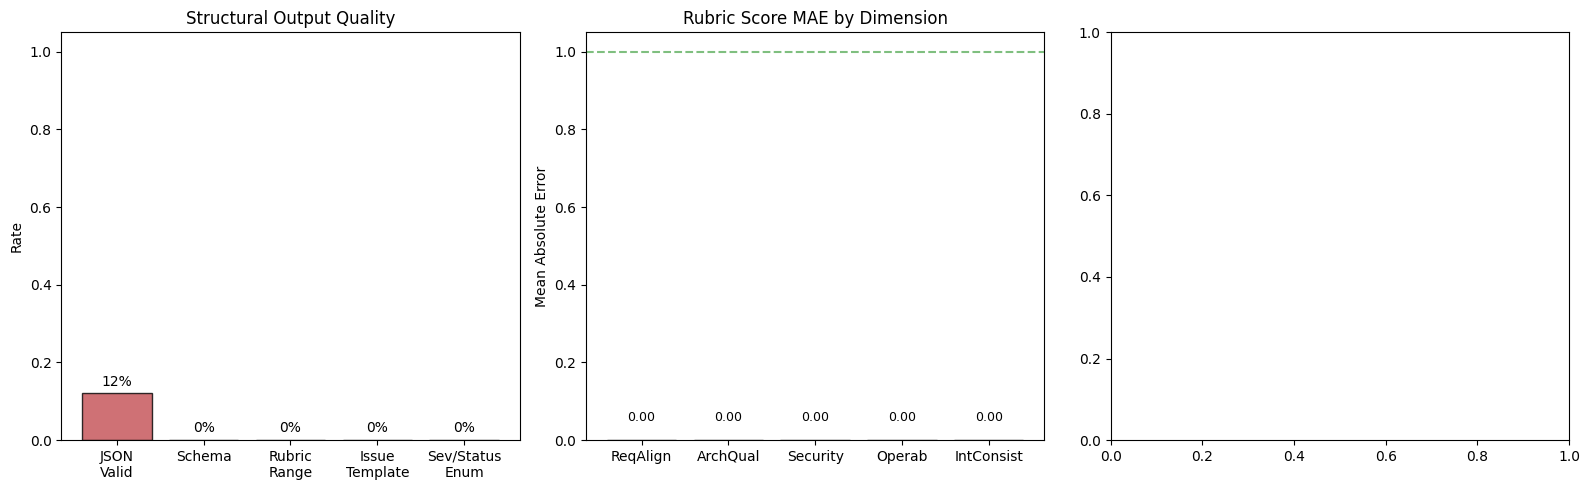

Saved evaluation_results.png


In [ ]:
# ═══════════════════════════════════════════════════════════════
# VISUALIZATION
# ═══════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Structural metrics
names = ['JSON\nValid', 'Schema', 'Rubric\nRange', 'Issue\nTemplate', 'Sev/Status\nEnum']
vals = list(structural.values())
colors = ['#55A868' if v > 0.7 else '#DD8452' if v > 0.4 else '#C44E52' for v in vals]
bars = axes[0].bar(names, vals, color=colors, edgecolor='black', alpha=0.8)
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel('Rate')
axes[0].set_title('Structural Output Quality')
for bar, val in zip(bars, vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val:.0%}', ha='center', fontsize=10)

# 2. Rubric MAE per dimension
dim_names = ['ReqAlign', 'ArchQual', 'Security', 'Operab', 'IntConsist']
dim_maes = [np.mean(rubric_errors[d]) if rubric_errors[d] else 0 for d in RUBRIC_DIMS]
mae_colors = ['#55A868' if m < 1.5 else '#DD8452' if m < 2.5 else '#C44E52' for m in dim_maes]
bars2 = axes[1].bar(dim_names, dim_maes, color=mae_colors, edgecolor='black', alpha=0.8)
axes[1].set_ylabel('Mean Absolute Error')
axes[1].set_title('Rubric Score MAE by Dimension')
axes[1].axhline(1.0, color='green', linestyle='--', alpha=0.5)
for bar, val in zip(bars2, dim_maes):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, f'{val:.2f}', ha='center', fontsize=9)

# 3. Predicted vs Reference scatter
pred_scores = []
ref_scores = []
for pred in predictions:
    p = pred['generated_parsed']
    r = pred['reference']
    if not p or not r:
        continue
    p_rub = p.get('rubricscores', p.get('rubric_scores', {}))
    r_rub = r.get('rubricscores', {})
    for d in RUBRIC_DIMS:
        pv = p_rub.get(d)
        rv = r_rub.get(d)
        if isinstance(pv, (int, float)) and isinstance(rv, (int, float)):
            pred_scores.append(pv)
            ref_scores.append(rv)

if pred_scores:
    axes[2].scatter(ref_scores, pred_scores, alpha=0.3, s=20, c='#8172B3')
    axes[2].plot([0,10], [0,10], 'r--', alpha=0.5)
    axes[2].set_xlabel('Reference Score')
    axes[2].set_ylabel('Predicted Score')
    axes[2].set_title('Predicted vs Reference Rubric Scores')
    axes[2].set_xlim(-0.5, 10.5)
    axes[2].set_ylim(-0.5, 10.5)
    from scipy import stats
    if len(pred_scores) > 2:
        r_val, p_val = stats.pearsonr(ref_scores, pred_scores)
        axes[2].annotate(f'r={r_val:.3f}', xy=(0.05, 0.92), xycoords='axes fraction')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'evaluation_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved evaluation_results.png")